In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy

plt.rcParams['figure.figsize'] = [20, 10]
import pandas as pd
import plotly.graph_objects as go
%matplotlib inline

In [ ]:
from google.colab import files
files.upload()

{}

In [ ]:
met_1 = pd.read_csv("/content/MET_1.dat", sep=",", parse_dates=["Date"], index_col="Date")
met_2 = pd.read_csv("/content/MET_2.dat", sep=",", parse_dates=["Date"], index_col="Date")
met_3 = pd.read_csv("/content/MET_3.dat", sep=",", parse_dates=["Date"], index_col="Date")
met_4 = pd.read_csv("/content/MET_4.dat", sep=",", parse_dates=["Date"], index_col="Date")
met_5 = pd.read_csv("/content/MET_5.dat", sep=",", parse_dates=["Date"], index_col="Date")
met_6 = pd.read_csv("/content/MET_6.dat", sep=",", parse_dates=["Date"], index_col="Date")

In [ ]:
met_lst = [met_1, met_2, met_3, met_4, met_5, met_6]
met_str_lst = ["met_1", "met_2", "met_3", "met_4", "met_5", "met_6"]
met_col_lst = ['Ppt','Tair','RH','Windspeed','Winddirection','Srad']

for i in met_lst:
    i.columns = i.columns.str.replace(' ','')
    i['Ppt'] = i['Ppt'].astype(float)
    i['Tair'] = i['Tair'].astype(float)
    i['RH'] = i['RH'].astype(float)
    i['Windspeed'] = i['Windspeed'].astype(float)
    i['Winddirection'] = i['Winddirection'].astype(float)
    i['Srad'] = i['Srad'].astype(float)

for i in range(len(met_lst)): 
    met_lst[i] = met_lst[i].reset_index()

In [ ]:
years = [str(item) for item in range(2015, 2022)]

def plot_dataframe(df, title, columns):
  for y in years:
    df.loc[y].resample('D').mean().plot(figsize=(12,6), y=columns, title=f"{title} {y}")

# Preliminary Weather Cleaning using Station Means

Cleaning Air Temperature, Relative Humidity, and Solar Radiation of all Stations. These are the features that don't change greatly between locations. Important since we are using means all stations.

In [ ]:
# removes spaces in the column names
def remove_spaces(df):
    df.columns = df.columns.str.replace(' ','')
    df['Ppt'] = df['Ppt'].astype(float)
    df['Tair'] = df['Tair'].astype(float)
    df['RH'] = df['RH'].astype(float)
    df['Windspeed'] = df['Windspeed'].astype(float)
    df['Winddirection'] = df['Winddirection'].astype(float)
    df['Srad'] = df['Srad'].astype(float)  

# save dataframes into list
DF = [met_1, met_2, met_3, met_4, met_5, met_6]

# remove column name spaces of each DataFrame 
for df in DF:
    remove_spaces(df)

In [ ]:
# Selects a feature from the data. Creates df with Stations as columns.
# Takes in list of dataframes and the selected feature as a string. 
def select_feature(DF, feature):
    df_feature = pd.concat(DF, axis=1)[feature]
    df_feature.columns = [str(f"Station{i}") for i in range(1, len(DF)+1)]
    return df_feature

In [ ]:
# Plots visual comparison of all stations' annual Sol Rad data. 
# Takes in df output of select_feature() and a string to be used as title
def plot_feature(df_feature, title):
    years = [str(yr) for yr in range(2014, 2022)]

    for yr in years:        
        df_yr = df_feature[yr].resample('D').mean()
        
        df_yr.plot(figsize=(12,6), title=f"{yr} {title}")
        df_yr.plot(figsize=(12,6), subplots=True, layout=(3,2))

In [ ]:
# imputes missing values with mean
def mean_imputation (df, df_mean):
    to_impute = df[df.isna() == True].index
    df[to_impute] = df_mean[to_impute]
    
    # document imputed indices
    return to_impute

# replaces values below given limit with mean
def mean_replace_low (df, df_mean, lim):
    to_replace = df[df < lim].index
    df[to_replace] = df_mean[to_replace]
    
    # document replaced indices
    return to_replace

In [ ]:
# for each station, set the values of the indices to clean as NaN to exclude them from the mean
def exclude_from_mean(df_feature, dict_):
    # make deep copy to not affect original
    df = df_feature.copy()
    
    # loop through each station data and set the values of the indices in dict_to_exclude to NaN.
    for station in dict_.keys():
        df[station][dict_[station]] = None
    
    # return the mean
    return df.mean(axis=1)

# replace the df_feature values of the station indices in dict_ with the df_mean values.
def mean_replace(df_feature, df_mean, dict_):
    
    for station in dict_.keys():  
        df_feature[station][dict_[station]] = df_mean[dict_[station]]

In [ ]:
# create df with only Air temp data of all Stations
df_Tair = select_feature(DF, "Tair")
# create df with only Rel Hum data of all Stations
df_RH = select_feature(DF, "RH")
# create df with only Sol Rad data of all Stations
df_Srad = select_feature(DF, "Srad")

In [ ]:
# Clean Tair Data

# 2018
# Exlude Station 1 and 5 Air Temp data from mean
df_2018_Tair_mean = df_Tair.drop(["Station1", "Station5"], axis=1).mean(axis=1)

# Record changed indices
S1_2018_imputed = mean_imputation (df_Tair["2018-4":"2018-8"].Station1, df_2018_Tair_mean)
S1_2018_replaced = mean_replace_low (df_Tair["2018-4":"2018-8"].Station1, df_2018_Tair_mean, -10)
S5_2018_imputed = mean_imputation (df_Tair["2018-4":"2018-5"].Station5, df_2018_Tair_mean)
S5_2018_replaced = mean_replace_low (df_Tair["2018-4":"2018-5"].Station5, df_2018_Tair_mean, -20)

# 2019
# Exlude Station 1 Air Temp data from mean
df_2019_Tair_mean = df_Tair.drop(["Station1"], axis=1).mean(axis=1)

# Record changed indices
S1_2019_replaced = mean_replace_low (df_Tair["2019-3"].Station1, df_2019_Tair_mean, -20)

In [ ]:
# Clean Srad Data

# 2018
# Exlude Station 1 and 5 Sol Rad data from mean
df_2018_Srad_mean = df_Srad.drop(["Station1", "Station5"], axis=1).mean(axis=1)

# Record changed indices
S1_2018_imputed = mean_imputation (df_Srad["2018-4":"2018-5"].Station1, df_2018_Srad_mean)
S5_2018_imputed = mean_imputation (df_Srad["2018-4":"2018-5"].Station5, df_2018_Srad_mean)

In [ ]:
# Clean RH Data

# Get idx to clean for each station


# Station 1
# get index of first NaN value
start = df_RH["2018-4"].Station1[df_RH["2018-4"].Station1.isnull() == True].index[0]
# get index of last value less than 1
end = df_RH["2018-8"].Station1[df_RH["2018-8"].Station1 < 1 ].index[-1]
# create index range to clean
idx_range = pd.date_range(start, end, freq="H")
S1_idx = idx_range


# Station 2
# get index of the values less than 1
idx_range = df_RH["2015-7":"2016-1"].Station2[df_RH["2015-7":"2016-1"].Station2 < 1 ].index
S2_idx = idx_range


# Station 3

# get index of first value less than 15 in 2018 Aug
start = df_RH["2018-8"].Station3[df_RH["2018-8"].Station3 < 15].index[0]
# get index of first value greater than 40 in 2019 Jul
end = df_RH["2019-7"].Station3[df_RH["2019-7"].Station3 > 40 ].index[0]
# create index range to clean
idx_range1 = pd.date_range(start, end, freq="H")

# get index of values less than 1 in 2019 Dec - 2020 Mar
idx_range2 = df_RH["2019-12":"2020-3"].Station3[df_RH["2019-12":"2020-3"].Station3 < 1].index
# get index of values less than 1 in 2020 Sep - 2021 Apr
idx_range3 = df_RH["2020-9":"2020-12"].Station3[df_RH["2020-9":"2020-12"].Station3 < 1].index

# get index of first value less than 5 in 2021 Jan
start = df_RH["2021-1"].Station3[df_RH["2021-1"].Station3 < 5].index[0]
# get index of last value less than 5 in 2021 Apr
end = df_RH["2021-4"].Station3[df_RH["2021-4"].Station3 < 5 ].index[-1]
# create index range to clean
idx_range4 = pd.date_range(start, end, freq="H")

S3_idx = (idx_range1.union(idx_range2)).union(idx_range3.union(idx_range4))



# Station 4

# get index of values less than 1 in 2021 Jun
idx = df_RH["2021-6"].Station4[df_RH["2021-6"].Station4 < 1].index

# create index range to clean
idx_range = pd.date_range(idx[0], idx[-1], freq="H")

S4_idx = idx_range



# Station 5

# get index of NaN values in 2018 Apr - May
idx_range1 = df_RH["2018-4":"2018-5"].Station5[df_RH["2018-4":"2018-5"].Station5.isnull() == True].index

# get index of values less than 1 in 2018 Apr - May
idx_range2 = df_RH["2018-4":"2018-5"].Station5[df_RH["2018-4":"2018-5"].Station5 < 1].index

# get index of values less than 1 in 2019
idx = df_RH["2019"].Station5[df_RH["2019"].Station5 < 1].index
# create 2019 index range to clean
idx_range3 = pd.date_range(idx[0], idx[-1], freq="H")

S5_idx = (idx_range1.union(idx_range2)).union(idx_range3)


# Station 6
# get index of values less than 10 in 2020 Jul - 2021 Feb
idx_range1 = df_RH["2020-7":"2021-2"].Station6[df_RH["2020-7":"2021-2"].Station6 < 10].index

# get index of values less than 10 in 2021 Jun - 2021 Aug
idx_range2 = df_RH["2021-6":"2021-8"].Station6[df_RH["2021-6":"2021-8"].Station6 < 10].index

S6_idx = idx_range1.union(idx_range2)


# Save Indices to Dictionary

# create dictionary with the indices to clean for each station. key name should match df_RH column name.
dict_idx_to_clean = {"Station1": S1_idx, "Station2": S2_idx, "Station3": S3_idx,\
                   "Station4": S4_idx, "Station5": S5_idx, "Station6": S6_idx}

In [ ]:
# Clean RH Data

# exclude data to clean from the mean
df_RH_mean = exclude_from_mean(df_RH, dict_idx_to_clean)

# Clean data by replacing values with mean
mean_replace(df_RH, df_RH_mean, dict_idx_to_clean)

Preliminary cleaning is done. New MET data of each station is saved in `met_lst_first_clean`

In [ ]:
# Revert cleaned data back to original format

stations = df_Tair.columns.values

for i in range(len(stations)):
    DF[i]["Tair"] = df_Tair[stations[i]]
  
    DF[i]["RH"] = df_RH[stations[i]]
    
    DF[i]["Srad"] = df_Srad[stations[i]]


# [met_1, met_2, ... , met_6]
met_lst_first_clean = DF

In [ ]:
met_lst_first_clean[0]

,Ppt,Tair,RH,Windspeed,Winddirection,Srad
Date,,,,,,
2014-10-01 00:00:00,0.0,22.13,80.70,1.429,203.2,0.0
2014-10-01 01:00:00,0.0,21.68,84.70,1.555,201.2,0.0
2014-10-01 02:00:00,0.0,22.21,89.20,2.288,193.1,0.0
2014-10-01 03:00:00,0.0,22.41,90.00,2.421,195.4,0.0
2014-10-01 04:00:00,0.0,22.30,92.60,1.738,191.3,0.0
...,...,...,...,...,...,...
2021-08-31 20:00:00,0.0,29.10,60.19,0.610,197.1,0.0
2021-08-31 21:00:00,0.0,28.07,62.28,0.510,199.6,0.0
2021-08-31 22:00:00,0.0,27.73,63.98,1.417,192.6,0.0


# Second filtering methods

In [ ]:
def tair_detec(station_lst, col_lst):

    for i in station_lst:
      # time_index = station_list[i].index()

        for col in col_lst:
            # Add restriction to Tair
            if col == "Tair":
                # Tempe ≤ 5°C from previous hourly record
                for idx in range(len(i)):
                    if idx > 1:                   
                        if i[col][idx] - i[col][idx-1] > 5:
                            print(i[col][idx] - i[col][idx-1])
                            print("outlier Tempe > 5°C found")
                            i[col][idx] = np.nan
                    elif np.abs(i[col][1] - i[col][0]) > 5:
                        i[col][1] = np.nan
                # Local record low ≥ Temp ≤ local record high
#                 i[i[col] < i[col].min and i[col] < i[col].max] = np.nan
                for idx in range(len(i)):
                    if i[col][idx] < -30 or i[col][idx] > 50:
                        print("air temp range outlier found")
                        i[col][idx] = np.nan

                # Temp varies ≥ 0.5°C over 12 consecutive hours, 
                # or per site specific climatology criteria
                for idx in range(len(i)):
                    if idx > 12:                   
                        if np.abs(i[col][idx] - i[col][idx-12]) < 0.5:
                            print(i[col][idx] - i[col][idx-12])
                            print("outlier Temp varies < 0.5°C found")
                            i[col][idx] = np.nan
                    elif np.abs(i[col][11] - i[col][0]) < 0.5:
                        i[col][11] = np.nan

        # station_lst[i].set_index(time_index) 

In [ ]:
def windspeed_detec(station, column):
    for i in station:
        for col in column:
            # Add restriction to wind speed
            if col == "Windspeed":
                # wind speed should be from 0-25 m/s
                for idx in range(len(i)):
                    if i[col][idx] < 0 or i[col][idx] > 25:
                        print("wind speed range outlier found")
                        i[col][idx] = np.nan

                # Wind speed varies ≥ 0.5m/s over 12 consecutive hours, 
                # or per site specific climatology criteria
                for idx in range(len(i)):
                    if idx > 12:                   
                        if np.abs(i[col][idx] - i[col][idx-12]) < 0.5:
                            print(i[col][idx] - i[col][idx-12])
                            print("outlier wind speed varies < 0.5m/s found")
                            i[col][idx] = np.nan
                    elif np.abs(i[col][11] - i[col][0]) < 0.5:
                        i[col][11] = np.nan
                            
                # Wind speed varies ≥ 0.1m/s over 3 consecutive hours, 
                for idx in range(len(i)):
                    if idx > 3:                   
                        if np.abs(i[col][idx] - i[col][idx-3]) < 0.1:
                            print(i[col][idx] - i[col][idx-3])
                            print("outlier wind speed varies < 0.1m/s found")
                            i[col][idx] = np.nan
                    elif np.abs(i[col][3] - i[col][0]) < 0.1:
                        i[col][3] = np.nan

In [ ]:
def winddir_detec(station, column):
    for i in station:
        for col in column:
            # Add restriction to Wind direction
            if col == "Winddirection":
                # 0 ≤ WD ≤ 360,
                for idx in range(len(i)):
                    if i[col][idx] < 0 or i[col][idx]>360:
                        pirnt(i[col][idx])
                        print("outlier wind direction out of range found")
                        i[col][idx] = np.nan
                # WD varies ≥ 1° 3 consecutive hours
                for idx in range(len(i)):
                    if idx > 3:                   
                        if np.abs(i[col][idx] - i[col][idx-3]) < 1:
                            print(i[col][idx] - i[col][idx-3])
                            print("outlier wind direction varies < 1 degree found")
                            i[col][idx] = np.nan
                    elif np.abs(i[col][3] - i[col][0]) < 1:
                        i[col][3] = np.nan

In [ ]:
def visualize_met_before(station, column, station_name):
  %matplotlib inline
  years = [str(item) for item in range(2014, 2022)]

  for i in years:
    station.loc[i][column].resample('D').mean().plot(figsize=(12,6))
    plt.title(station_name + " " + str(i))
    plt.show()

In [ ]:
def visualize_met_after(station, column, station_name):
  %matplotlib inline
  years = [str(item) for item in range(2014, 2022)]

  for i in years:
    station.set_index('Date').loc[i][column].resample('D').mean().plot(figsize=(12,6))
    plt.title(station_name + " " + str(i))
    plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

KeyboardInterrupt: ignored

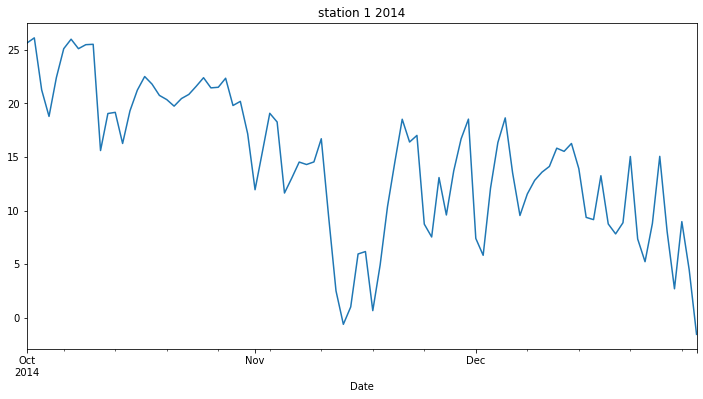

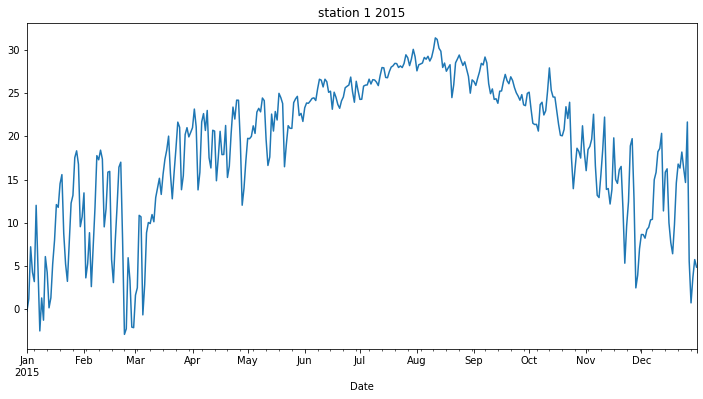

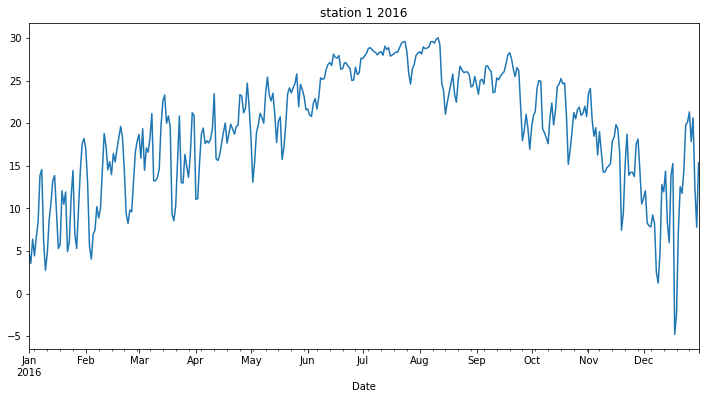

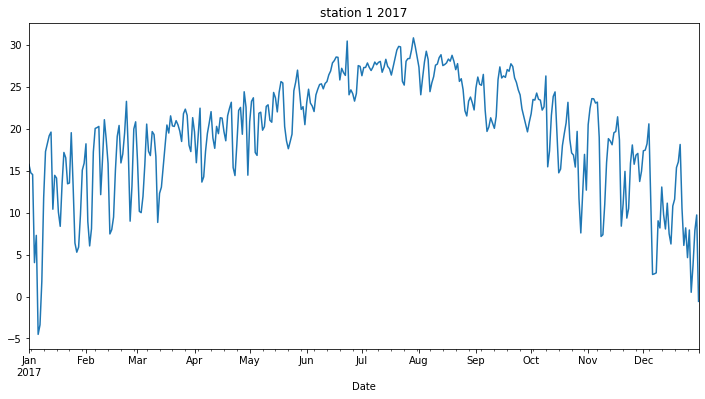

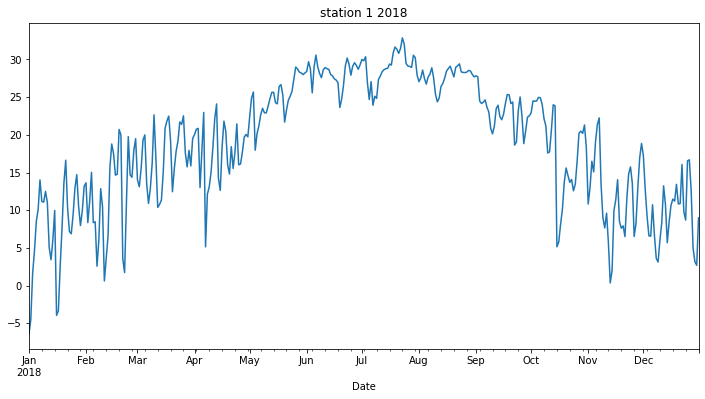

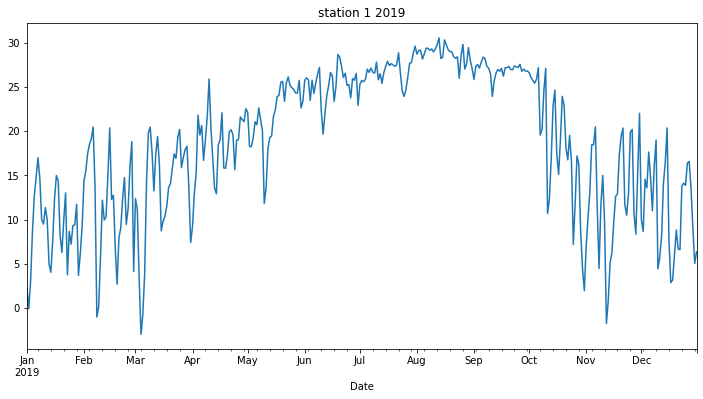

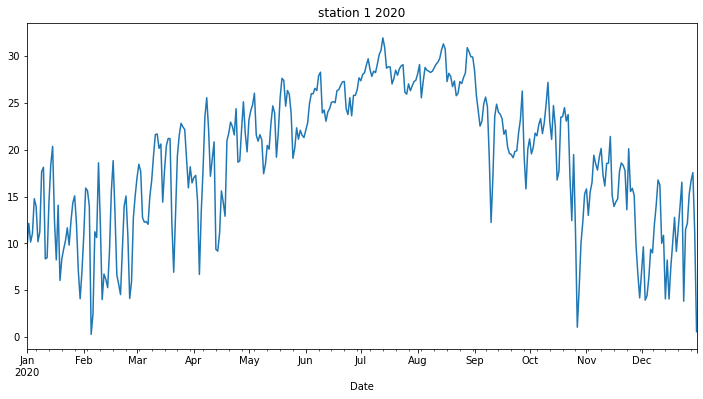

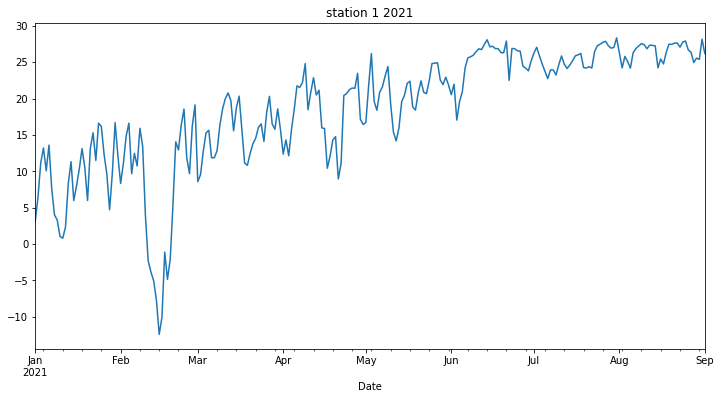

In [ ]:
visualize_met_before(met_lst_first_clean[0],"Tair","station 1")

# Second cleaning (range filter)

In [ ]:
met_lst_second_clean = met_lst_first_clean.copy()

tair_detec(met_lst_second_clean ,met_col_lst)
windspeed_detec(met_lst_second_clean ,met_col_lst)
winddir_detec(met_lst_second_clean ,met_col_lst)

Streaming output truncated to the last 5000 lines.
0.8999999999999773
outlier wind direction varies < 1 degree found
0.8000000000000114
outlier wind direction varies < 1 degree found
-0.6999999999999886
outlier wind direction varies < 1 degree found
0.8000000000000114
outlier wind direction varies < 1 degree found
-0.4000000000000057
outlier wind direction varies < 1 degree found
-0.5
outlier wind direction varies < 1 degree found
0.799999999999983
outlier wind direction varies < 1 degree found
0.5
outlier wind direction varies < 1 degree found
-0.30000000000001137
outlier wind direction varies < 1 degree found
0.20000000000004547
outlier wind direction varies < 1 degree found
-0.4000000000000057
outlier wind direction varies < 1 degree found
0.29999999999998295
outlier wind direction varies < 1 degree found
0.8000000000000114
outlier wind direction varies < 1 degree found
0.5999999999999943
outlier wind direction varies < 1 degree found
0.6000000000000227
outlier wind direction varies

In [ ]:
met_lst_second_clean[0]

,Ppt,Tair,RH,Windspeed,Winddirection,Srad
Date,,,,,,
2014-10-01 00:00:00,0.0,22.13,80.70,1.429,203.2,0.0
2014-10-01 01:00:00,0.0,21.68,84.70,1.555,201.2,0.0
2014-10-01 02:00:00,0.0,22.21,89.20,2.288,193.1,0.0
2014-10-01 03:00:00,0.0,22.41,90.00,2.421,195.4,0.0
2014-10-01 04:00:00,0.0,22.30,92.60,1.738,191.3,0.0
...,...,...,...,...,...,...
2021-08-31 20:00:00,0.0,29.10,60.19,NaN,197.1,0.0
2021-08-31 21:00:00,0.0,NaN,62.28,0.510,199.6,0.0
2021-08-31 22:00:00,0.0,27.73,63.98,NaN,192.6,0.0


# Fill in missing (NaN) values using imputation

In [ ]:
# select column values to fill, only middle values
# (no na values if at very beginning or very end of dataset)
def df_fillna_middle_column(df, column):
  return df[column][df[column].bfill().notnull() & df[column].ffill().notnull()]

# imputes missing data for a given station using the mean of available data from other stations
def fill_using_mean_of_other_stations(df, current_df_index, df_list):
  df_fill = df.copy()

  for column in df.columns:
    new_column_df = pd.DataFrame()

    for index, d in enumerate(df_list):
      if index != current_df_index:
        new_column_df[index] = d[column]

    df_fill[column] = df_fillna_middle_column(df_fill, column).fillna(new_column_df.mean(axis=1))

  return df_fill



# Finish cleaning MET data

In [ ]:
met_lst_clean_final = []

for index, df in enumerate(met_lst_second_clean):
  met_lst_clean_final.append(fill_using_mean_of_other_stations(df, index, met_lst_second_clean))

met_lst_clean_final[0]



,Ppt,Tair,RH,Windspeed,Winddirection,Srad
Date,,,,,,
2014-10-01 00:00:00,0.0,22.130,80.70,1.429,203.2,0.0
2014-10-01 01:00:00,0.0,21.680,84.70,1.555,201.2,0.0
2014-10-01 02:00:00,0.0,22.210,89.20,2.288,193.1,0.0
2014-10-01 03:00:00,0.0,22.410,90.00,2.421,195.4,0.0
2014-10-01 04:00:00,0.0,22.300,92.60,1.738,191.3,0.0
...,...,...,...,...,...,...
2021-08-31 20:00:00,0.0,29.100,60.19,1.029,197.1,0.0
2021-08-31 21:00:00,0.0,29.595,62.28,0.510,199.6,0.0
2021-08-31 22:00:00,0.0,27.730,63.98,NaN,192.6,0.0


# Write clean MET data into csv files
# (Very Important) ^^


In [ ]:
for index, df in enumerate(met_lst_clean_final):
  df.to_csv(f"met_data{index + 1}_cleaned.csv")

# Precipitation/soil moisture validation code (Tyler)

In [ ]:
years = [str(item) for item in range(2015, 2022)]

for i in years:
    q,a,wl,sl,myRainl, myMois, perMois, perRainl=Compare(df_soil1[i].SWC_5, ppt1[i],.15,2, .07,2 )
    ql, al, w, s, myRain, myMoisl, perMoisl, perRain=Compare(df_soil1[i].SWC_5, ppt1[i], .1, 5, .03, 5)
    print("Percent of explained moisture peaks in year "+i+ " station 1: ", perMois)
    print("Percent of explained rain peaks in year " + i+ " station 1:", perRain)

    q,a,wl,sl,myRainl, myMois, perMois, perRainl=Compare(df_soil2[i].SWC_5, ppt2[i],.15,2, .07,2 )
    ql, al, w, s, myRain, myMoisl, perMoisl, perRain=Compare(df_soil2[i].SWC_5, ppt2[i], .1, 5, .03, 5)
    print("Percent of explained moisture peaks in year "+i+ " station 2: ", perMois)
    print("Percent of explained rain peaks in year " + i+ " station 2:", perRain)
    q,a,wl,sl,myRainl, myMois, perMois, perRainl=Compare(df_soil3[i].SWC_5, ppt3[i],.15,2, .07,2 )
    ql, al, w, s, myRain, myMoisl, perMoisl, perRain=Compare(df_soil3[i].SWC_5, ppt3[i], .1, 5, .03, 5)
    print("Percent of explained moisture peaks in year "+i+ " station 3: ", perMois)
    print("Percent of explained rain peaks in year " + i+ " station 3:", perRain)
    q,a,wl,sl,myRainl, myMois, perMois, perRainl=Compare(df_soil4[i].SWC_5, ppt4[i],.15,2, .07,2 )
    ql, al, w, s, myRain, myMoisl, perMoisl, perRain=Compare(df_soil4[i].SWC_5, ppt4[i], .1, 5, .03, 5)
    print("Percent of explained moisture peaks in year "+i+ " station 4: ", perMois)
    print("Percent of explained rain peaks in year " + i+ " station 4:", perRain)
    q,a,wl,sl,myRainl, myMois, perMois, perRainl=Compare(df_soil5[i].SWC_5, ppt5[i],.15,2, .07,2 )
    ql, al, w, s, myRain, myMoisl, perMoisl, perRain=Compare(df_soil5[i].SWC_5, ppt5[i], .1, 5, .03, 5)
    print("Percent of explained moisture peaks in year "+i+ " station 5: ", perMois)
    print("Percent of explained rain peaks in year " + i+ " station 5:", perRain)
    q,a,wl,sl,myRainl, myMois, perMois, perRainl=Compare(df_soil6[i].SWC_5, ppt6[i],.15,2, .07,2 )
    ql, al, w, s, myRain, myMoisl, perMoisl, perRain=Compare(df_soil6[i].SWC_5, ppt6[i], .1, 5, .03, 5)
    print("Percent of explained moisture peaks in year "+i+ " station 6: ", perMois)
    print("Percent of explained rain peaks in year " + i+ " station 6:", perRain)


Percent of explained moisture peaks in year 2015 station 1:  77.77777777777777
Percent of explained rain peaks in year 2015 station 1: 100.0
Percent of explained moisture peaks in year 2015 station 2:  100.0
Percent of explained rain peaks in year 2015 station 2: 85.71428571428571
Percent of explained moisture peaks in year 2015 station 3:  100.0
Percent of explained rain peaks in year 2015 station 3: 95.83333333333333
Percent of explained moisture peaks in year 2015 station 4:  100.0
Percent of explained rain peaks in year 2015 station 4: 80.0
Percent of explained moisture peaks in year 2015 station 5:  100.0
Percent of explained rain peaks in year 2015 station 5: 77.27272727272727
Percent of explained moisture peaks in year 2015 station 6:  100.0
Percent of explained rain peaks in year 2015 station 6: 100.0
Percent of explained moisture peaks in year 2016 station 1:  40.0
Percent of explained rain peaks in year 2016 station 1: 90.9090909090909
Percent of explained moisture peaks in y

In [ ]:
years = [str(item) for item in range(2015, 2022)]

for i in years:
    q,a, myMois, perMois=Compare2(df_soil1[i].SWC_5, ppt1[i] )
    print("Percent of explained moisture peaks in year "+i+ " station 1: ", perMois)
    q,a, myMois, perMois=Compare2(df_soil2[i].SWC_5, ppt2[i] )
    print("Percent of explained moisture peaks in year "+i+ " station 2: ", perMois)
    q,a, myMois, perMois=Compare2(df_soil3[i].SWC_5, ppt3[i] )
    print("Percent of explained moisture peaks in year "+i+ " station 3: ", perMois)
    q,a, myMois, perMois=Compare2(df_soil4[i].SWC_5, ppt4[i] )
    print("Percent of explained moisture peaks in year "+i+ " station 4: ", perMois)
    q,a, myMois, perMois=Compare2(df_soil5[i].SWC_5, ppt5[i] )
    print("Percent of explained moisture peaks in year "+i+ " station 5: ", perMois)
    q,a, myMois, perMois=Compare2(df_soil6[i].SWC_5, ppt6[i] )
    print("Percent of explained moisture peaks in year "+i+ " station 6: ", perMois)

    

In [ ]:
def findPeaks(SWC5, thresh, rainpoint):
    peaks=[]
    index=[]
    cooldown=24
    forward_window=12
    backWindow=-12
    '''
    peaks- values of where we say it rains
    index- index at which it rains
    cooldown- minimum number of points between one rain point and another
    rainPoint- threshold difference to constitue rain
    forwardWindow- how far forward window checks to make sure slope does not continue to increase
    backWindow- how far back it checks the differences in rain values
    '''
    for i in range(-backWindow,len(SWC5)-forward_window):
        c=SWC5[i]
        #Loops through all hours within the year, except boundry hours
        
        go=True
        #If a greater value detected in the near future, not at a peak
        for l in range(1,forward_window):
            if c<SWC5[i+l]:
                go=False
            #If at a possible peak
            if go:
                for j in range(backWindow,0):
                    #If signifigantly greater than some point in the past and value is greater than some threshold value, mark as a perak
                    if c-SWC5[i+j]>rainpoint and c>thresh:
                        peaks.append(SWC5[i])
                        index.append(i)
                        break
    #Gets rid of peaks that are within cooldown of each other- unmark the lower peak
    for i in range(len(peaks)-1,0,-1):
        if index[i]-index[i-1]<cooldown:
            if peaks[i]>peaks[i-1]:
                peaks.pop(i-1)
                index.pop(i-1)
            else:
                peaks.pop(i)
                index.pop(i)
    return index, peaks

In [ ]:
def Compare(SWC5, ppt, t, t2, r, r2):


    q,a=findPeaks(SWC5, t, r)
    w,s=findPeaks(ppt, t2, r2)
    #The arrays below will be the corrosponding elements in q and 2 and subsequently a and s which match
    myrainIndex=np.full(len(w), False)
    myMoistureIndex=np.full(len(q), False)
    for rainIndex in range(len(w)):
        #Checks all rain indecies
        for i in range(len(q)):
            #Against all moisture points
            for t in range(-24,25):
                #If within a windoow of 48 hours, these twon points match!
                if w[rainIndex]==q[i]+t:
                    myrainIndex[rainIndex]=True
                    myMoistureIndex[i]=True
                    break
    q=np.array(q)
    a=np.array(a)
    w=np.array(w)
    s=np.array(s)
    percentMoisture=100*len(q[myMoistureIndex==True])/len(q)
    #Percentage of matching moisture and rain points, respectively
    percentRain=100*len(w[myrainIndex==True])/len(w)
    return q, a, w, s, myrainIndex, myMoistureIndex, percentMoisture, percentRain

In [ ]:
def findIncreasing(SWC5):
    peaks=[]
    index=[]
    backWindow=-1
    '''
    peaks- values of where we say it rains
    index- index at which it rains
    cooldown- minimum number of points between one rain point and another
    rainPoint- threshold difference to constitue rain
    forwardWindow- how far forward window checks to make sure slope does not continue to increase
    backWindow- how far back it checks the differences in rain values
    '''
    for i in range(12,len(SWC5)):
        c=SWC5[i]
        record=False
        #Loops through all hours within the year, except boundry hours
        #If signifigantly greater than some point in the past and value is greater than some threshold value, mark as a perak
        for j in range(-12,-6):
            if c-SWC5[i+j]>0.03:
                record=True
                break
        if record:    
            peaks.append(SWC5[i])
            index.append(i)
    return index, peaks
    

In [ ]:
def Compare2(SWC5, ppt):

    #Should I also check all non-zeros rainvalues with some increase in soil moisture?
    q,a=findIncreasing(SWC5)
    #The arrays below will be the corrosponding elements in q and 2 and subsequently a and s which match
    myMoistureIndex=np.full(len(q), False)
    for rainIndex in range(len(q)):
        #Checks all rain indecies
        for t in range(-24,1):
                #If within a windoow of 48 hours, these twon points match!
                if ppt[q[rainIndex]+t]!=0:
                    myMoistureIndex[rainIndex]=True
                    break
    q=np.array(q)
    a=np.array(a)
    percentMoisture=100*len(q[myMoistureIndex==True])/len(q)
    #Percentage of matching moisture and rain points, respectively
    return q, a, myMoistureIndex, percentMoisture

# Soil processing code

In [ ]:
# Read and set the index to be the date

df_soil1 = pd.read_csv('/content/sample_data/SM_1.dat', sep=",", parse_dates=["Date"], index_col="Date")

# pandas remove spaces in the column names
df_soil1.columns = df_soil1.columns.str.replace(' ','')
df_soil1['SWC_5'] = df_soil1['SWC_5'].astype(float)
df_soil1['SWC_10'] = df_soil1['SWC_10'].astype(float)
df_soil1['SWC_20'] = df_soil1['SWC_20'].astype(float)
df_soil1['SWC_50'] = df_soil1['SWC_50'].astype(float)

df_soil1['T_5'] = df_soil1['T_5'].astype(float)
df_soil1['T_10'] = df_soil1['T_10'].astype(float)
df_soil1['T_20'] = df_soil1['T_20'].astype(float)
df_soil1['T_50'] = df_soil1['T_50'].astype(float)

df_soil1['Ppt'] = df_soil1['Ppt'].astype(float)
ppt1=df_soil1['Ppt']
df_soil2 = pd.read_csv('/content/sample_data/SM_2.dat', sep=",", parse_dates=["Date"], index_col="Date")

# pandas remove spaces in the column names
df_soil2.columns = df_soil2.columns.str.replace(' ','')
df_soil2['SWC_5'] = df_soil2['SWC_5'].astype(float)
df_soil2['SWC_10'] = df_soil2['SWC_10'].astype(float)
df_soil2['SWC_20'] = df_soil2['SWC_20'].astype(float)
df_soil2['SWC_50'] = df_soil2['SWC_50'].astype(float)

df_soil2['T_5'] = df_soil2['T_5'].astype(float)
df_soil2['T_10'] = df_soil2['T_10'].astype(float)
df_soil2['T_20'] = df_soil2['T_20'].astype(float)
df_soil2['T_50'] = df_soil2['T_50'].astype(float)

df_soil2['Ppt'] = df_soil2['Ppt'].astype(float)
ppt2=df_soil2['Ppt']
df_soil3 = pd.read_csv('/content/sample_data/SM_3.dat', sep=",", parse_dates=["Date"], index_col="Date")

# pandas remove spaces in the column names
df_soil3.columns = df_soil3.columns.str.replace(' ','')
df_soil3['SWC_5'] = df_soil3['SWC_5'].astype(float)
df_soil3['SWC_10'] = df_soil3['SWC_10'].astype(float)
df_soil3['SWC_20'] = df_soil3['SWC_20'].astype(float)
df_soil3['SWC_50'] = df_soil3['SWC_50'].astype(float)

df_soil3['T_5'] = df_soil3['T_5'].astype(float)
df_soil3['T_10'] = df_soil3['T_10'].astype(float)
df_soil3['T_20'] = df_soil3['T_20'].astype(float)
df_soil3['T_50'] = df_soil3['T_50'].astype(float)

df_soil3['Ppt'] = df_soil3['Ppt'].astype(float)
ppt3=df_soil3['Ppt']
df_soil4 = pd.read_csv('/content/sample_data/SM_4.dat', sep=",", parse_dates=["Date"], index_col="Date")

# pandas remove spaces in the column names
df_soil4.columns = df_soil4.columns.str.replace(' ','')
df_soil4['SWC_5'] = df_soil4['SWC_5'].astype(float)
df_soil4['SWC_10'] = df_soil4['SWC_10'].astype(float)
df_soil4['SWC_20'] = df_soil4['SWC_20'].astype(float)
df_soil4['SWC_50'] = df_soil4['SWC_50'].astype(float)

df_soil4['T_5'] = df_soil4['T_5'].astype(float)
df_soil4['T_10'] = df_soil4['T_10'].astype(float)
df_soil4['T_20'] = df_soil4['T_20'].astype(float)
df_soil4['T_50'] = df_soil4['T_50'].astype(float)

df_soil4['Ppt'] = df_soil4['Ppt'].astype(float)
ppt4=df_soil4['Ppt']
df_soil5 = pd.read_csv('/content/sample_data/SM_5.dat', sep=",", parse_dates=["Date"], index_col="Date")

# pandas remove spaces in the column names
df_soil5.columns = df_soil5.columns.str.replace(' ','')
df_soil5['SWC_5'] = df_soil5['SWC_5'].astype(float)
df_soil5['SWC_10'] = df_soil5['SWC_10'].astype(float)
df_soil5['SWC_20'] = df_soil5['SWC_20'].astype(float)
df_soil5['SWC_50'] = df_soil5['SWC_50'].astype(float)

df_soil5['T_5'] = df_soil5['T_5'].astype(float)
df_soil5['T_10'] = df_soil5['T_10'].astype(float)
df_soil5['T_20'] = df_soil5['T_20'].astype(float)
df_soil5['T_50'] = df_soil5['T_50'].astype(float)

df_soil5['Ppt'] = df_soil5['Ppt'].astype(float)
ppt5=df_soil5['Ppt']
df_soil6 = pd.read_csv('/content/sample_data/SM_6.dat', sep=",", parse_dates=["Date"], index_col="Date")

# pandas remove spaces in the column names
df_soil6.columns = df_soil6.columns.str.replace(' ','')
df_soil6['SWC_5'] = df_soil6['SWC_5'].astype(float)
df_soil6['SWC_10'] = df_soil6['SWC_10'].astype(float)
df_soil6['SWC_20'] = df_soil6['SWC_20'].astype(float)
df_soil6['SWC_50'] = df_soil6['SWC_50'].astype(float)

df_soil6['T_5'] = df_soil6['T_5'].astype(float)
df_soil6['T_10'] = df_soil6['T_10'].astype(float)
df_soil6['T_20'] = df_soil6['T_20'].astype(float)
df_soil6['T_50'] = df_soil6['T_50'].astype(float)

df_soil6['Ppt'] = df_soil6['Ppt'].astype(float)
ppt6=df_soil6['Ppt']